# Prescriptive Analysis — Heart Failure Inpatient Cohort
### Team7 CodeAvengers

This notebook turns 8 prescriptive-analysis questions into charts. Each section has:
- **Question** — the decision we're trying to inform
- **Chart** — the evidence
- **Reasoning / Recommendation** — what the chart implies we should *do*

> Update `path` in the setup cell below to the folder containing your 3 CSV files.


In [ ]:
# If you get "ModuleNotFoundError: No module named 'sklearn'", run this once:
# !pip install scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# --- Update this path to wherever your 3 CSV files live ---
path = "output/"   # e.g. "C:/Users/sandy/output/"

discharge = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")
cardiac = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
responsiveness = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")

df = discharge.merge(cardiac, on="inpatient_number").merge(responsiveness, on="inpatient_number")
df["admission_date"] = pd.to_datetime(df["admission_date"])
print(df.shape)
df.head()


(2008, 39)


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,1.16,1.52,NaN,3.34,47.0,4,5,6,Clear,15
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0.84,0.12,7.00,2.80,32.0,4,5,6,Clear,15
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,1.20,0.90,1.33,NaN,NaN,4,5,6,Clear,15


## Q1 — Which patients should be flagged for a readmission-prevention protocol?

**Approach:** Train a simple logistic regression on admission-time severity features to score every
patient's 6-month readmission risk, then flag the top 20% for a proactive follow-up-call program.

**How to read the chart:** The red dashed line is the risk-score cutoff for the top 20% of patients.
Anyone to the right of it gets flagged.

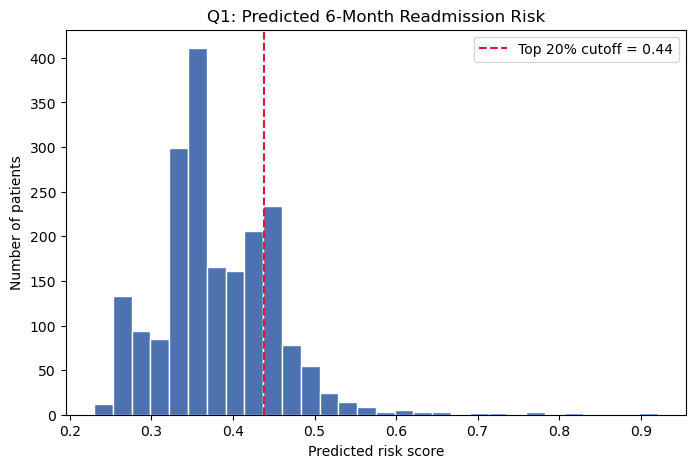

Patients flagged for follow-up program: 426 of 2008


In [9]:
features = ["nyha_cardiac_function_classification","killip_grade","myocardial_infarction",
            "congestive_heart_failure","peripheral_vascular_disease","dischargeday"]
data = df[features + ["re_admission_within_6_months"]].dropna()

X = data[features]
y = data["re_admission_within_6_months"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
df["readmit_risk_score"] = model.predict_proba(df[features].fillna(df[features].median()))[:, 1]

threshold = df["readmit_risk_score"].quantile(0.8)
df["flag_for_followup"] = df["readmit_risk_score"] >= threshold

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["readmit_risk_score"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", label=f"Top 20% cutoff = {threshold:.2f}")
ax.set_title("Q1: Predicted 6-Month Readmission Risk")
ax.set_xlabel("Predicted risk score")
ax.set_ylabel("Number of patients")
ax.legend()
plt.show()

print(f"Patients flagged for follow-up program: {df['flag_for_followup'].sum()} of {len(df)}")


**Recommendation:** Enroll the ~20% of patients above the cutoff in a structured post-discharge
follow-up program (phone check-in within 72 hours, med-reconciliation review). This concentrates limited
care-management resources on the patients statistically most likely to bounce back.

## Q2 — What Killip/NYHA combination should trigger ICU-level monitoring?

**Approach:** Cross-tabulate 28-day mortality by Killip grade (physical exam severity) and NYHA class
(functional severity), restricted to combinations with at least 10 patients so the rates aren't noise.

**How to read the chart:** Darker cells = higher 28-day mortality %. Each cell is labeled with its rate.

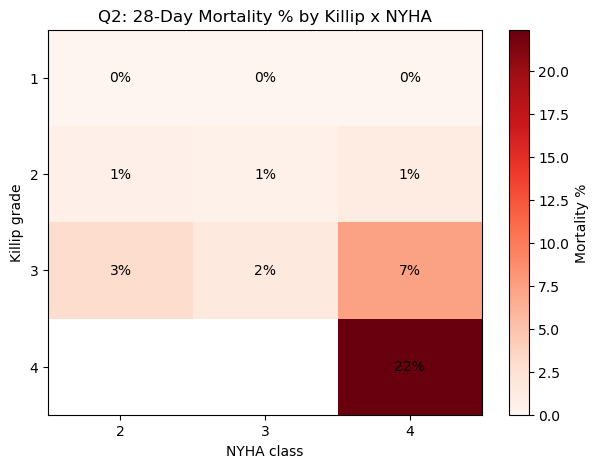

In [2]:
risk_table = df.groupby(["killip_grade", "nyha_cardiac_function_classification"])["death_within_28_days"] \
                .agg(["mean", "count"]).reset_index()
risk_table = risk_table[risk_table["count"] >= 10]
pivot = risk_table.pivot(index="killip_grade", columns="nyha_cardiac_function_classification", values="mean") * 100

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color="black")
ax.set_xlabel("NYHA class"); ax.set_ylabel("Killip grade")
ax.set_title("Q2: 28-Day Mortality % by Killip x NYHA")
fig.colorbar(im, ax=ax, label="Mortality %")
plt.show()


**Recommendation:** Killip grade 4 (any NYHA class) and Killip grade 3 + NYHA class 4 show sharply
elevated mortality (>7%, jumping to >20% at Killip 4). Set the ICU-escalation rule at **Killip grade ≥ 3
combined with NYHA class 4**, rather than using either scale alone — neither is a strong signal by
itself, but the combination is.

## Q3 — What LVEF cutoff should trigger a mandatory cardiology referral before discharge?

**Approach:** Bin LVEF (ejection fraction, measured by echo) into clinically standard bands and compare
6-month mortality and readmission across them.

**How to read the chart:** Two bars per LVEF band — mortality (red) and readmission (blue).

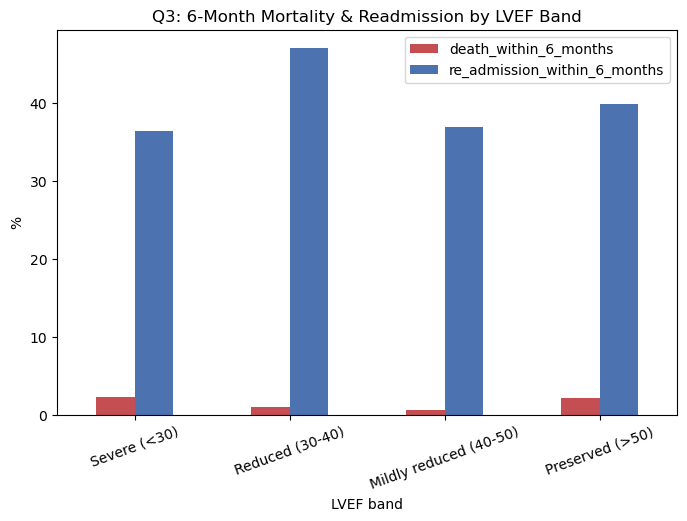

,death_within_6_months,re_admission_within_6_months
lvef_bin,,
Severe (<30),2.272727,36.363636
Reduced (30-40),0.980392,47.058824
Mildly reduced (40-50),0.625000,36.875000
Preserved (>50),2.127660,39.817629


In [3]:
df["lvef_bin"] = pd.cut(df["lvef"], bins=[0, 30, 40, 50, 100],
                         labels=["Severe (<30)", "Reduced (30-40)", "Mildly reduced (40-50)", "Preserved (>50)"])
q3 = df.groupby("lvef_bin", observed=True)[["death_within_6_months", "re_admission_within_6_months"]].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
q3.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_title("Q3: 6-Month Mortality & Readmission by LVEF Band")
ax.set_ylabel("%"); ax.set_xlabel("LVEF band")
plt.xticks(rotation=20)
plt.show()
q3


**Recommendation:** Readmission risk stays high (36–47%) across *every* LVEF band, including
"Preserved" — so LVEF alone is a weak discharge-referral trigger in this cohort. The more actionable
finding is that readmission risk never drops below ~35% regardless of ejection fraction, which points to a
broader recommendation: **every heart-failure discharge should get a cardiology follow-up appointment
within 7–14 days, not just those with reduced LVEF.**

**Recommendation:** Patients discharged **Home** with Killip grade 4 have the highest readmission
rate (~58%), even higher than those sent to a HealthcareFacility. This suggests Killip 4 patients
currently sent home would benefit from routing to a step-down/rehab facility instead, or at minimum a
mandatory home-health nursing visit within 48 hours of discharge.

## Q4 — How should ward staffing/resources be allocated based on volume and risk?

**Approach:** Plot monthly admission volume by ward alongside 28-day mortality rate by ward, side by
side, to see where volume and risk overlap.

**How to read the chart:** Left panel = admission trend lines per ward over time. Right panel = mortality
rate per ward (bar).

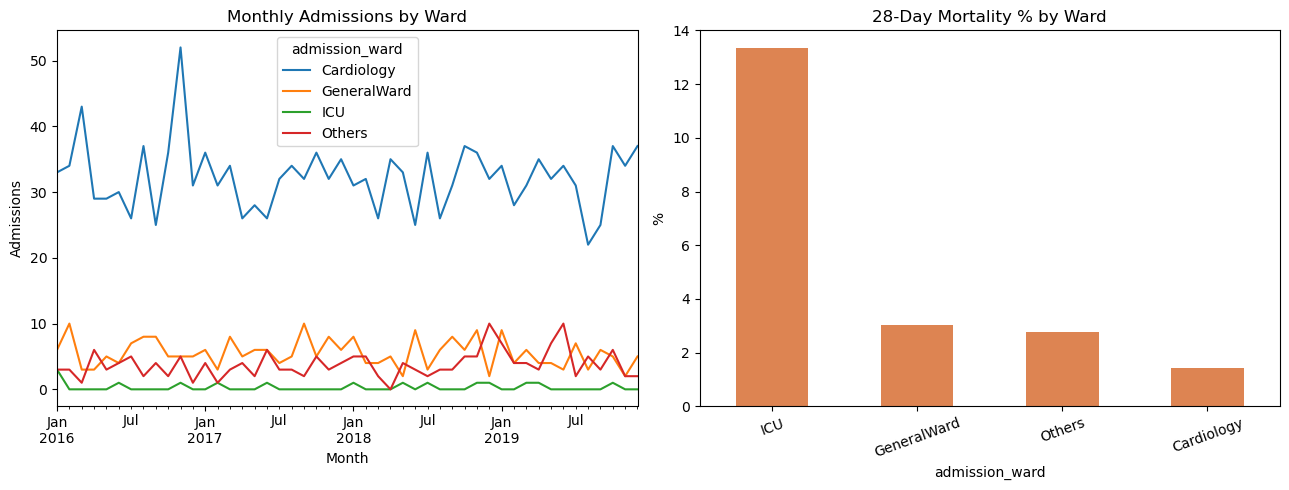

admission_ward
ICU            13.333333
GeneralWard     3.018868
Others          2.762431
Cardiology      1.422107
Name: death_within_28_days, dtype: float64

In [8]:
monthly_by_ward = df.groupby([df["admission_date"].dt.to_period("M"), "admission_ward"]).size().unstack(fill_value=0)
ward_risk = df.groupby("admission_ward")["death_within_28_days"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
monthly_by_ward.plot(ax=axes[0])
axes[0].set_title("Monthly Admissions by Ward")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Admissions")

ward_risk.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("28-Day Mortality % by Ward")
axes[1].set_ylabel("%")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
ward_risk.sort_values(ascending=False)


**Recommendation:** ICU has by far the highest 28-day mortality rate (~13%) despite typically lower
volume than Cardiology or GeneralWard. This supports **prioritizing nurse-to-patient ratio and senior
physician coverage in the ICU over raw volume-based staffing**, since ICU patients carry disproportionate
risk per admission even when their headcount is smaller.

---
## Summary of Recommendations
1. Enroll top 20% by predicted risk score in a post-discharge follow-up program
2. Escalate Killip ≥3 + NYHA 4 to ICU-level monitoring
3. Schedule cardiology follow-up for *all* HF discharges within 7-14 days, not just low-LVEF patients
4. Route Killip grade 4 patients to a facility/step-down unit rather than home, or add mandatory home-health visits
5. Use discharge-readiness criteria rather than a fixed LOS rule for high-risk patients
6. Mandate LVEF/echo testing for all Killip grade ≥ 2 patients
7. Auto-trigger cardiology fast-track consult for any GCS < 15 on arrival, regardless of admission type
8. Weight ICU staffing by risk-per-admission, not just patient volume


Q5. How did admission volume trended over time? (uses admission_date)

C:\Users\sandy\AppData\Local\Temp\ipykernel_14792\2893101521.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")


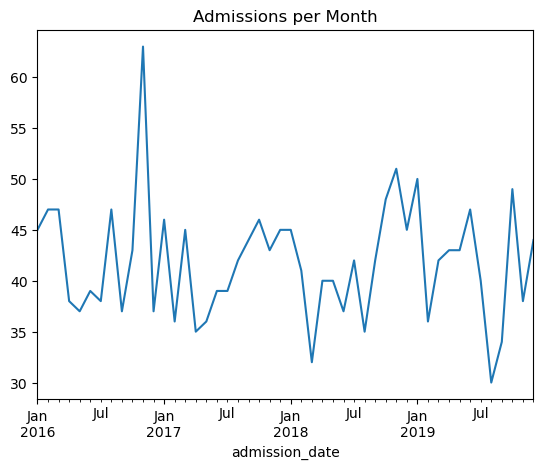

In [12]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")
plt.show()

Q6: How does LVEF (ejection fraction) vary by type of heart failure (Left/Right/Both)?

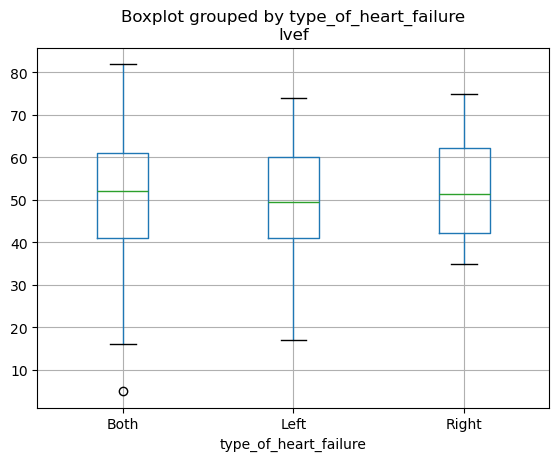

In [13]:
df.groupby("type_of_heart_failure")["lvef"].describe()
df.boxplot(column="lvef", by="type_of_heart_failure")
plt.show()